# Baseline XGBoost — N-CMAPSS DS02 (flota completa)
### TFM: Arquitectura de Mantenimiento Predictivo con ingesta en tiempo real

Baseline de predicción de **RUL** sobre **DS02** usando **los 9 motores** (split dev/test
propio del dataset, que cubre las tres clases de vuelo). Integra lo bueno del pipeline
previo (arquitectura *predecir-luego-agregar*, features de tendencia, score NASA,
incertidumbre) **corrigiendo la fuga de información** detectada.

**Por qué XGBoost (y no HistGradientBoostingRegressor):** continuidad con el pipeline
previo, importancia nativa por *gain* (necesaria para el chequeo anti-leakage) y es el
estándar en la literatura de RUL/N-CMAPSS. HistGBR sería una alternativa válida y de
rendimiento similar, sin dependencias extra.

**Cambios respecto al notebook anterior (Fc=3, motor 2):**
- ❌ Se elimina `cycle_norm`: era *leakage* (codifica el RUL y exige conocer el ciclo de
  fallo, que en tiempo real no se conoce). En el modelo previo se llevaba el 0.96 de la
  importancia y daba R²=1.0 en train.
- ✅ Edad del motor como `age = cycle` crudo (sí es conocida en tiempo real).
- ✅ `Fc` (clase de vuelo) entra como **feature**, en vez de entrenar un modelo por clase
  (DS02 tiene pocos motores por clase). Comparar "modelo único con Fc" vs "un modelo por
  Fc" queda como experimento para la memoria.
- ✅ Sin `StandardScaler` (no aporta a XGBoost, que es invariante a escala).
- ✅ Sin `X_v`, `T` ni `hs` (no observables en un motor real).
- ✅ Submuestreo del flujo para que el coste sea manejable con 6 motores a 1 Hz.

> Las métricas honestas serán peores que el 3.6 de RMSE anterior (ese número era artefacto
> del leakage). En N-CMAPSS un RMSE realista suele estar en ~6–12 ciclos.

In [20]:
# Instalación (descomentar si hace falta)
# !pip install xgboost optuna joblib scikit-learn h5py numpy pandas matplotlib

In [21]:
import h5py, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'savefig.bbox': 'tight',
                     'axes.grid': True, 'font.size': 10})

# ---- Constantes ----
FILE_PATH      = 'C:\\Users\\11jav\\Documents\\Master\\TFM\\Dataset_Nasa\\Turbofan_Engine_degradation\\Datasets\\data_set\\data_set\\N-CMAPSS_DS02-006.h5'   # ajusta la ruta
SEED           = 42
SUBSAMPLE      = 10        # 1 de cada N lecturas para entrenar (coste manejable)
VAL_N_UNITS    = 1         # nº de motores de dev reservados a validación
ROLL_WINDOWS   = (5, 10)
SLOPE_W        = 10
RUN_OPTUNA     = False     # ponlo en True para tunear (lento)
N_TRIALS       = 30
np.random.seed(SEED)
print('XGBoost', xgb.__version__, '| subsample 1/%d' % SUBSAMPLE)

XGBoost 3.2.0 | subsample 1/10


## 1. Carga (flota completa, split propio del dataset)

Cargamos `W` + `X_s` + auxiliares + `Y`. Excluimos `hs` (no observable) y no tocamos
`X_v` ni `T`. El split dev/test es el del fichero: nunca mezclamos un motor entre ambos.

In [22]:
def load_ds(path, split):
    with h5py.File(path, 'r') as f:
        W   = np.array(f[f'W_{split}'],   dtype=np.float32)
        X_s = np.array(f[f'X_s_{split}'], dtype=np.float32)
        A   = np.array(f[f'A_{split}'],   dtype=np.float32)
        Y   = np.array(f[f'Y_{split}'],   dtype=np.float32)
        W_var  = [v.decode() for v in f['W_var'][:]]
        Xs_var = [v.decode() for v in f['X_s_var'][:]]
        A_var  = [v.decode() for v in f['A_var'][:]]
    # quitar hs del bloque auxiliar
    if 'hs' in A_var:
        i = A_var.index('hs'); A = np.delete(A, i, axis=1); A_var = [v for v in A_var if v != 'hs']
    df = pd.DataFrame(np.hstack([A, W, X_s, Y.reshape(-1, 1)]),
                      columns=A_var + W_var + Xs_var + ['RUL'])
    for c in ['unit', 'cycle', 'Fc']:
        df[c] = df[c].astype(int)
    return df, W_var, Xs_var

df_dev,  W_var, Xs_var = load_ds(FILE_PATH, 'dev')
df_test, _, _          = load_ds(FILE_PATH, 'test')
print('dev :', df_dev.shape, '| motores', sorted(df_dev.unit.unique()))
print('test:', df_test.shape, '| motores', sorted(df_test.unit.unique()))

dev : (5263447, 22) | motores [np.int64(2), np.int64(5), np.int64(10), np.int64(16), np.int64(18), np.int64(20)]
test: (1253743, 22) | motores [np.int64(11), np.int64(14), np.int64(15)]


In [23]:
# Inventario rápido
for nm, d in [('DEV', df_dev), ('TEST', df_test)]:
    print(f'\n[{nm}]')
    for u in sorted(d.unit.unique()):
        s = d[d.unit == u]
        fc = s.Fc.mode().iloc[0]
        print(f'  unit {u:2d} | Fc={fc} | ciclos={s.cycle.nunique():3d} | '
              f'obs={len(s):>9,} | RUL[{s.RUL.min():.0f},{s.RUL.max():.0f}]')


[DEV]


  unit  2 | Fc=3 | ciclos= 75 | obs=  853,142 | RUL[0,74]
  unit  5 | Fc=3 | ciclos= 89 | obs=1,033,420 | RUL[0,88]
  unit 10 | Fc=3 | ciclos= 82 | obs=  952,711 | RUL[0,81]
  unit 16 | Fc=3 | ciclos= 63 | obs=  765,295 | RUL[0,62]
  unit 18 | Fc=3 | ciclos= 71 | obs=  890,719 | RUL[0,70]
  unit 20 | Fc=3 | ciclos= 66 | obs=  768,160 | RUL[0,65]

[TEST]
  unit 11 | Fc=3 | ciclos= 59 | obs=  663,495 | RUL[0,58]
  unit 14 | Fc=1 | ciclos= 76 | obs=  156,778 | RUL[0,75]
  unit 15 | Fc=2 | ciclos= 67 | obs=  433,470 | RUL[0,66]


## 2. Feature engineering (sin leakage)

Replicamos los bloques útiles del pipeline previo, separando por coste:

- **Por observación** (varían dentro del vuelo): sensores `X_s` y condiciones `W` crudos,
  más `pos_relativa` (posición normalizada dentro del vuelo: distingue despegue/crucero/descenso).
- **Por ciclo** (constantes dentro del vuelo): media móvil inter-ciclo (ventanas 5 y 10),
  desviación móvil, *slope* inter-ciclo (tendencia de degradación) y estadísticos
  intra-ciclo (`max`, `std`). Se calculan una vez a nivel de ciclo y se unen por *merge*.
- **Contexto:** `Fc` (clase de vuelo) y `age = cycle` (edad del motor).

Las features por ciclo se calculan **por unidad** (`groupby('unit')`), sin mezclar
historiales de motores distintos. El *merge* se hace tras submuestrear el train, para no
materializar una matriz de millones de filas × ~120 columnas.

In [24]:
def cycle_level_features(df, sensors, windows=ROLL_WINDOWS, slope_w=SLOPE_W):
    """Una fila por (unit, cycle): rolling mean/std, slope inter-ciclo e intra-ciclo max/std."""
    df = df.sort_values(['unit', 'cycle'])
    cyc = df.groupby(['unit', 'cycle'])[sensors].mean().reset_index().sort_values(['unit', 'cycle'])

    roll_cols = []
    for w in windows:
        for col in sensors:
            cyc[f'{col}_roll{w}_mean'] = cyc.groupby('unit')[col].transform(
                lambda x: x.rolling(w, min_periods=1).mean())
            cyc[f'{col}_roll{w}_std'] = cyc.groupby('unit')[col].transform(
                lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            roll_cols += [f'{col}_roll{w}_mean', f'{col}_roll{w}_std']

    def slope(x, w):
        a = x.values; out = np.zeros(len(a))
        for i in range(len(a)):
            seg = a[max(0, i - w + 1): i + 1]
            if len(seg) >= 2:
                out[i] = np.polyfit(np.arange(len(seg)), seg, 1)[0]
        return pd.Series(out, index=x.index)
    for col in sensors:
        cyc[f'{col}_slope{slope_w}'] = cyc.groupby('unit')[col].transform(lambda x: slope(x, slope_w))
        roll_cols.append(f'{col}_slope{slope_w}')

    stats = df.groupby(['unit', 'cycle'])[sensors].agg(['max', 'std'])
    stats.columns = [f'{s}_cyc_{a}' for s, a in stats.columns]
    stats = stats.fillna(0.0).reset_index()

    out = cyc[['unit', 'cycle'] + roll_cols].merge(stats, on=['unit', 'cycle'])
    return out

In [25]:
def add_pos_relativa(df):
    df = df.sort_values(['unit', 'cycle']).reset_index(drop=True)
    pos = df.groupby(['unit', 'cycle']).cumcount()
    size = df.groupby(['unit', 'cycle'])['cycle'].transform('size') - 1
    df['pos_relativa'] = (pos / size.replace(0, 1)).astype(np.float32)
    return df

def assemble(df, cyc_feat, sensors, w_var, subsample=None, seed=SEED):
    """Une features por-observación + por-ciclo. Submuestrea observaciones si subsample."""
    df = add_pos_relativa(df)
    obs = df[['unit', 'cycle', 'Fc', 'RUL'] + sensors + w_var + ['pos_relativa']]
    if subsample:
        obs = obs.sample(frac=1.0 / subsample, random_state=seed)
    obs = obs.copy()
    obs['age'] = obs['cycle'].astype(np.float32)
    return obs.merge(cyc_feat, on=['unit', 'cycle'], how='left')

In [26]:
SENSORS = Xs_var   # rolling/slope/intra se calculan sobre los sensores físicos

print('Calculando features por ciclo (dev y test)...'); t0 = time.time()
cyc_dev  = cycle_level_features(df_dev,  SENSORS)
cyc_test = cycle_level_features(df_test, SENSORS)
print(f'  OK ({time.time()-t0:.1f}s)')

# Split por unidad: reservamos los últimos VAL_N_UNITS motores de dev para validación
units_dev   = sorted(df_dev.unit.unique())
val_units   = units_dev[-VAL_N_UNITS:]
train_units = units_dev[:-VAL_N_UNITS]
print('train units:', train_units, '| val units:', val_units,
      '| test units:', sorted(df_test.unit.unique()))

print('Ensamblando matrices...'); t0 = time.time()
train_mat = assemble(df_dev[df_dev.unit.isin(train_units)], cyc_dev, SENSORS, W_var, subsample=SUBSAMPLE)
val_mat   = assemble(df_dev[df_dev.unit.isin(val_units)],   cyc_dev, SENSORS, W_var, subsample=None)
test_mat  = assemble(df_test,                               cyc_test, SENSORS, W_var, subsample=None)
print(f'  OK ({time.time()-t0:.1f}s)')

FEATURES = [c for c in train_mat.columns if c not in ('unit', 'cycle', 'RUL')]
print(f'\n{len(FEATURES)} features | train {len(train_mat):,} obs (submuestreado) | '
      f'val {len(val_mat):,} | test {len(test_mat):,}')
assert 'cycle_norm' not in FEATURES, 'cycle_norm no debe estar (leakage)'  

Calculando features por ciclo (dev y test)...


  OK (47.5s)
train units: [np.int64(2), np.int64(5), np.int64(10), np.int64(16), np.int64(18)] | val units: [np.int64(20)] | test units: [np.int64(11), np.int64(14), np.int64(15)]
Ensamblando matrices...
  OK (55.1s)

119 features | train 449,529 obs (submuestreado) | val 768,160 | test 1,253,743


## 3. Métricas y agregación por ciclo

Arquitectura *predecir-luego-agregar*: el modelo predice RUL en cada lectura; la
predicción definitiva del vuelo es la **mediana** de las lecturas (robusta), y la
dispersión intra-ciclo (`std`, IQR) da una estimación de incertidumbre. Todas las métricas
se calculan sobre el RUL **agregado por ciclo**, que es el objetivo real.

In [27]:
def nasa_score(y_true, y_pred):
    d = np.asarray(y_pred) - np.asarray(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

def aggregate_by_cycle(model, mat):
    p = model.predict(mat[FEATURES].values)
    t = mat[['unit', 'cycle', 'RUL']].copy(); t['pred'] = p
    g = t.groupby(['unit', 'cycle']).agg(
        RUL_real=('RUL', 'first'), RUL_med=('pred', 'median'),
        RUL_p25=('pred', lambda x: x.quantile(.25)),
        RUL_p75=('pred', lambda x: x.quantile(.75)),
        RUL_std=('pred', 'std')).reset_index()
    return g

def report(g, label):
    rmse = mean_squared_error(g.RUL_real, g.RUL_med) ** .5
    mae  = mean_absolute_error(g.RUL_real, g.RUL_med)
    r2   = r2_score(g.RUL_real, g.RUL_med)
    s    = nasa_score(g.RUL_real, g.RUL_med)
    print(f'  [{label:5s}] RMSE={rmse:6.3f}  MAE={mae:6.3f}  R2={r2:.4f}  NASA={s:8.1f}')
    return rmse

## 4. Entrenamiento

Baseline con parámetros razonables y *early stopping* contra los motores de validación
(submuestreados solo para el set de parada, para que sea rápido). Optuna queda opcional.

In [28]:
X_tr, y_tr = train_mat[FEATURES].values, train_mat['RUL'].values
val_es = val_mat.sample(frac=1.0 / SUBSAMPLE, random_state=SEED)   # set de early stopping
X_es, y_es = val_es[FEATURES].values, val_es['RUL'].values

base_params = dict(n_estimators=600, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                   reg_lambda=1.0, reg_alpha=0.1, gamma=0.0,
                   random_state=SEED, n_jobs=-1, importance_type='gain',
                   eval_metric='rmse', early_stopping_rounds=30)

print('Entrenando baseline...'); t0 = time.time()
model = xgb.XGBRegressor(**base_params)
model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
print(f'  OK ({time.time()-t0:.1f}s) | best_iteration={model.best_iteration}')
report(aggregate_by_cycle(model, val_mat), 'VAL')

Entrenando baseline...
  OK (118.1s) | best_iteration=39
  [VAL  ] RMSE= 7.906  MAE= 6.506  R2=0.8278  NASA=    75.1


7.905602470086582

In [29]:
if RUN_OPTUNA:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    def objective(trial):
        p = dict(
            n_estimators=trial.suggest_int('n_estimators', 200, 1000),
            max_depth=trial.suggest_int('max_depth', 3, 9),
            learning_rate=trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.4, 1.0),
            min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
            gamma=trial.suggest_float('gamma', 0, 5),
            random_state=SEED, n_jobs=-1, importance_type='gain',
            eval_metric='rmse', early_stopping_rounds=30)
        m = xgb.XGBRegressor(**p)
        m.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
        g = aggregate_by_cycle(m, val_mat)
        return mean_squared_error(g.RUL_real, g.RUL_med) ** .5
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print('Mejor RMSE val:', round(study.best_value, 4))
    best = {**base_params, **study.best_params}
    model = xgb.XGBRegressor(**best)
    model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
else:
    print('Optuna desactivado (RUN_OPTUNA=False). Usando baseline.')

Optuna desactivado (RUN_OPTUNA=False). Usando baseline.


## 5. Evaluación

In [30]:
print('Métricas (RUL agregado por ciclo):')
g_tr   = aggregate_by_cycle(model, train_mat); report(g_tr, 'TRAIN')
g_val  = aggregate_by_cycle(model, val_mat);   report(g_val, 'VAL')
g_test = aggregate_by_cycle(model, test_mat);  report(g_test, 'TEST')

Métricas (RUL agregado por ciclo):


  [TRAIN] RMSE= 3.275  MAE= 2.801  R2=0.9794  NASA=   112.2
  [VAL  ] RMSE= 7.906  MAE= 6.506  R2=0.8278  NASA=    75.1
  [TEST ] RMSE= 9.485  MAE= 7.935  R2=0.7761  NASA=   299.7


9.48488096493284

El test (RMSE 9,49) sale peor que la validación (7,91). En lugar de optimizar a ciegas, lo
**diagnosticamos por hipótesis**: planteamos tres explicaciones posibles y las contrastamos con
los datos, en este orden:

1. **Hipótesis 1 — Clase de vuelo:** el test es peor porque contiene clases de vuelo (Fc=1/2)
   que el entrenamiento no vio (todo Fc=3).
2. **Hipótesis 2 — Vidas cortas:** el modelo falla en motores cuya vida total queda fuera del
   rango visto en entrenamiento (63–89 ciclos).
3. **Hipótesis 3 — La feature `age`:** la feature más importante quizá induce el sesgo
   ("mirar la edad" en vez de la degradación).

Anticipamos el resultado: **dos se refutan y una se confirma**. Documentar también las hipótesis
refutadas es parte del método: evita que las decisiones parezcan arbitrarias.

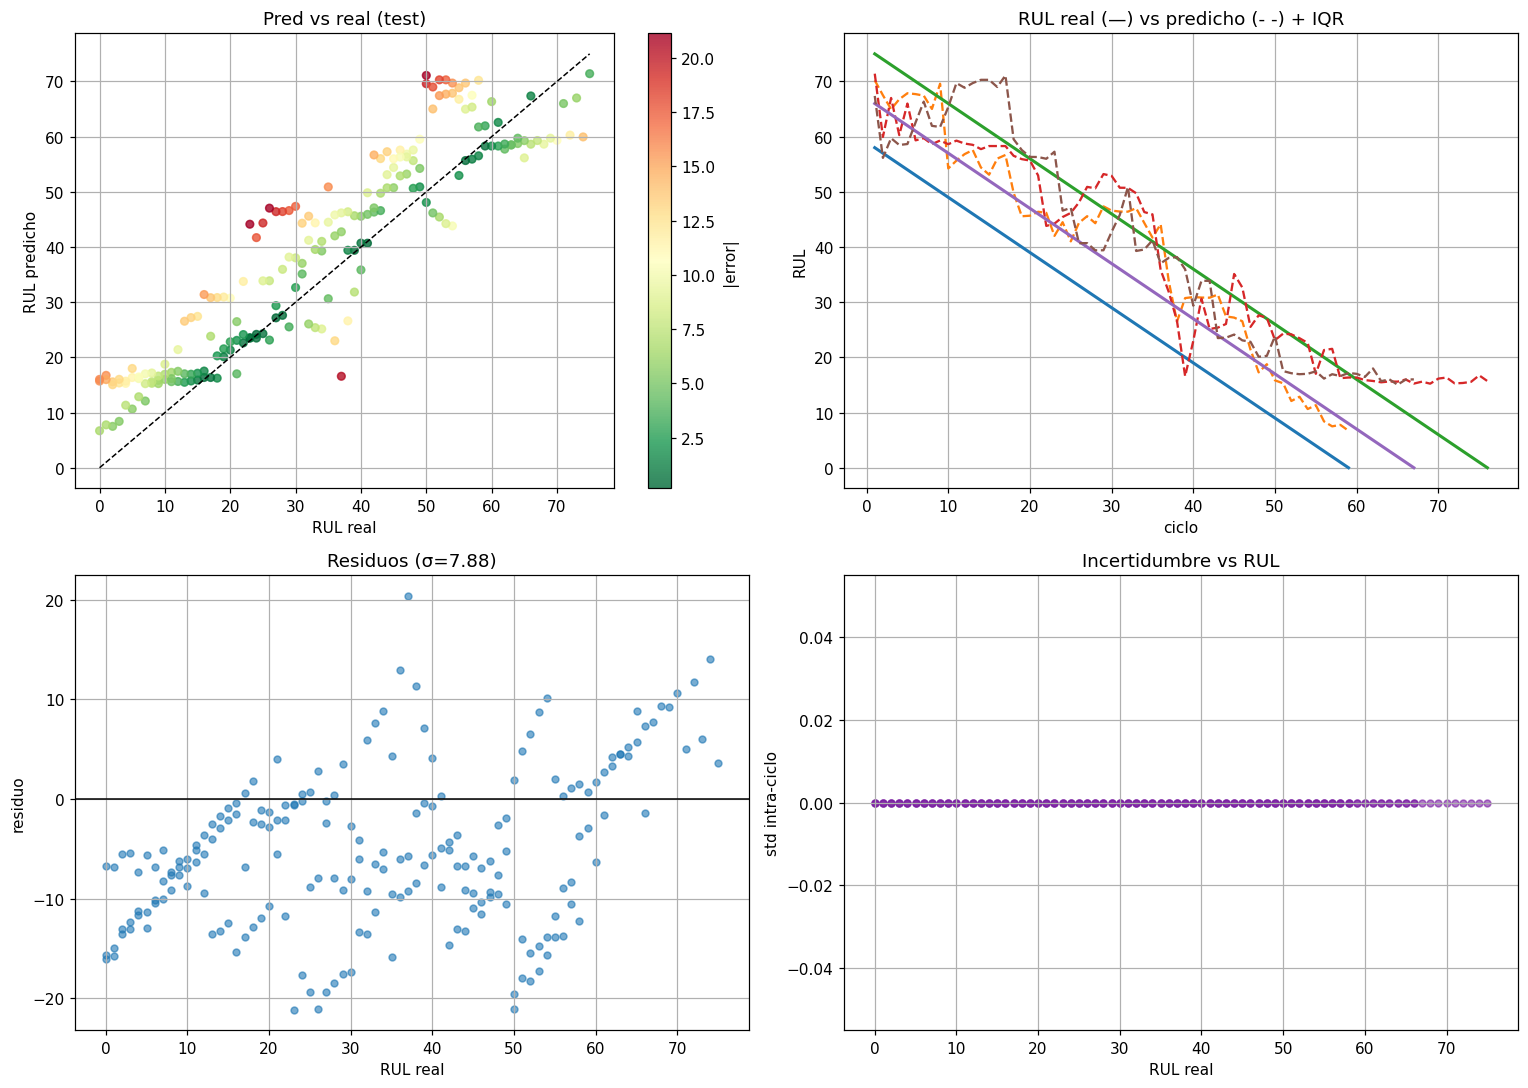

In [31]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# Pred vs real (test)
err = (g_test.RUL_real - g_test.RUL_med).abs()
sc = ax[0,0].scatter(g_test.RUL_real, g_test.RUL_med, c=err, cmap='RdYlGn_r', s=25, alpha=.8)
lim = [0, max(g_test.RUL_real.max(), g_test.RUL_med.max())]
ax[0,0].plot(lim, lim, 'k--', lw=1); plt.colorbar(sc, ax=ax[0,0], label='|error|')
ax[0,0].set_xlabel('RUL real'); ax[0,0].set_ylabel('RUL predicho'); ax[0,0].set_title('Pred vs real (test)')

# Trayectorias por motor de test
for u in sorted(g_test.unit.unique()):
    s = g_test[g_test.unit == u].sort_values('cycle')
    ax[0,1].plot(s.cycle, s.RUL_real, lw=2)
    ax[0,1].plot(s.cycle, s.RUL_med, '--', lw=1.5)
    ax[0,1].fill_between(s.cycle, s.RUL_p25, s.RUL_p75, alpha=.15)
ax[0,1].set_xlabel('ciclo'); ax[0,1].set_ylabel('RUL'); ax[0,1].set_title('RUL real (—) vs predicho (- -) + IQR')

# Residuos
res = g_test.RUL_real - g_test.RUL_med
ax[1,0].scatter(g_test.RUL_real, res, s=20, alpha=.6)
ax[1,0].axhline(0, color='k', lw=1)
ax[1,0].set_xlabel('RUL real'); ax[1,0].set_ylabel('residuo'); ax[1,0].set_title(f'Residuos (σ={res.std():.2f})')

# Incertidumbre vs RUL
ax[1,1].scatter(g_test.RUL_real, g_test.RUL_std, s=20, alpha=.6, color='#7B1FA2')
ax[1,1].set_xlabel('RUL real'); ax[1,1].set_ylabel('std intra-ciclo'); ax[1,1].set_title('Incertidumbre vs RUL')
plt.tight_layout(); plt.savefig('xgb_ds02_eval.png'); plt.show()

### Hipótesis 1 — El error viene de la clase de vuelo

**Hipótesis:** el test es peor porque el modelo se evalúa sobre clases de vuelo (Fc=1/2) que no
vio en entrenamiento (todo Fc=3).

**Cómo la comprobamos:** desglosamos el error del test por motor y por Fc.

**Resultado:** REFUTADA. El motor de test de clase vista (unit 11, Fc=3) fue el **peor**, y los
de clases no vistas (u14, u15) no son los que disparan el error. Meter `Fc` como feature tampoco
ayudaría, porque en entrenamiento vale siempre 3.

**Consecuencia:** el problema no es la clase de vuelo. Buscamos otra causa (Hipótesis 2).

In [ ]:
# Desglose del test por motor y por clase de vuelo
fc_por_unit = df_test.groupby('unit')['Fc'].first()
filas = []
for u in sorted(g_test.unit.unique()):
    s = g_test[g_test.unit == u]
    filas.append({
        'unit': u, 'Fc': int(fc_por_unit[u]), 'ciclos': len(s),
        'RMSE': mean_squared_error(s.RUL_real, s.RUL_med) ** .5,
        'MAE':  mean_absolute_error(s.RUL_real, s.RUL_med),
        'R2':   r2_score(s.RUL_real, s.RUL_med),
        'NASA': nasa_score(s.RUL_real, s.RUL_med),
        'NASA_x_ciclo': nasa_score(s.RUL_real, s.RUL_med) / len(s),
    })
desg = pd.DataFrame(filas).sort_values('Fc')
print(desg.to_string(index=False))
print('\nMedia RMSE solo Fc=3 (vista en train) vs resto:')
print(' Fc=3:', round(desg[desg.Fc == 3]['RMSE'].mean(), 3),
      '| Fc!=3:', round(desg[desg.Fc != 3]['RMSE'].mean(), 3))

 unit  Fc  ciclos      RMSE       MAE       R2       NASA  NASA_x_ciclo
   14   1      76  7.185677  5.704939 0.892709  60.086483      0.790612
   15   2      67  9.179500  7.569321 0.774697  97.190216      1.450600
   11   3      59 12.075122 11.222013 0.497212 142.374084      2.413120

Media RMSE solo Fc=3 (vista en train) vs resto:
 Fc=3: 12.075 | Fc!=3: 8.183


**Lectura del desglose:** queda **refutada** la hipótesis de la clase de vuelo. Supusimos que el
modelo iría bien en la unidad de la clase vista (u11, Fc=3) y mal en las clases nuevas (u14 Fc=1,
u15 Fc=2). Ha sido **justo al revés**: la unidad de la clase vista en entrenamiento es la peor con
diferencia (u11: RMSE 12,1, R² 0,50), y las dos clases "no vistas" van mejor (u14: RMSE 7,2,
R² 0,89). La historia del desbalance de clase de vuelo **no se sostiene con estos datos**. Además,
añadir `Fc` como feature tampoco ayudaría: en entrenamiento vale siempre 3, no aporta variación.
Toca corregir el rumbo: pasamos a la Hipótesis 2.

### Hipótesis 2 — El error viene de extrapolar a vidas cortas

**Hipótesis:** el modelo falla en motores cuya vida total es más corta que las vistas en
entrenamiento (63–89 ciclos).

**Cómo la comprobamos:** comparamos el sesgo de cada motor de test con su vida total.

**Resultado:** CONFIRMADA. La unit 11 (vida 59, más corta que cualquier motor de train) es la
más sesgada (sobreestima). El sesgo crece cuanto más corta es la vida frente al rango de train.

**Consecuencia:** el reto real es la generalización a vidas fuera de rango. Se aborda al escalar
a la flota completa (más variedad de vidas), en la Fase 2.

**La pista que apunta a la Hipótesis 2:** la unit 11 vive únicamente **59 ciclos**, menos que
cualquier motor de entrenamiento (63–89). El modelo nunca vio un motor que fallara tan pronto.
Dos indicios sugieren que por eso sobreestima:

- En la unit 11, MAE (11,2) y RMSE (12,1) casi coinciden: el error no es ruido disperso sino un
  **sesgo sistemático** (un offset casi constante). En las otras unidades el MAE queda claramente
  por debajo del RMSE (error más repartido).
- La dirección del error es consistente: siempre hacia arriba (predice más vida de la real).

**Comprobación:** calculamos el sesgo medio (predicho − real) de cada motor de test y lo
comparamos con su vida total. Si la unit 11 sale con sesgo claramente positivo, queda confirmado
que sobreestima por su vida corta.

In [ ]:
train_lives = df_dev[df_dev.unit.isin(train_units)].groupby('unit').cycle.max()
print('Vidas en train:', sorted(train_lives.values), '| val u20:', int(df_dev[df_dev.unit==20].cycle.max()))
print('\nSesgo por motor de test (RUL_pred - RUL_real); >0 = sobreestima = peligroso:')
for u in sorted(g_test.unit.unique()):
    s = g_test[g_test.unit == u]
    print(f'  unit {u} (Fc={int(df_test[df_test.unit==u].Fc.iloc[0])}, vida {len(s)}): '
          f'sesgo medio = {(s.RUL_med - s.RUL_real).mean():+.2f}')

Vidas en train: [np.int64(63), np.int64(71), np.int64(75), np.int64(82), np.int64(89)] | val u20: 66

Sesgo por motor de test (RUL_pred - RUL_real); >0 = sobreestima = peligroso:
  unit 11 (Fc=3, vida 59): sesgo medio = +11.22
  unit 14 (Fc=1, vida 76): sesgo medio = -0.70
  unit 15 (Fc=2, vida 67): sesgo medio = +6.92


**Resultado: CONFIRMADA.** La unit 11 (vida 59, **más corta que cualquier motor de
entrenamiento**) sobreestima de media **+11,2 ciclos**. La unit 15 (vida 67, en el límite bajo del
rango) sobreestima **+6,9**. Y la unit 14 (vida 76, plenamente dentro del rango visto) está casi
perfecta: **−0,7**. Es decir: **cuanto más corta es la vida respecto a lo visto en train, más
sobreestima el modelo**. Y el sesgo es positivo en los dos casos cortos, que es justo la
dirección peligrosa (decir que al motor le queda más vida de la real).

**Consecuencia:** el reto real del proyecto es la generalización a vidas fuera de rango. No se
resuelve con hiperparámetros: se aborda escalando a la flota completa (Fase 2), que aporta
variedad de vidas y de modos de fallo.

### Hipótesis 3 — La feature `age` induce el sesgo (ablation)

**Hipótesis:** como `age` es la feature más importante, quizá el modelo "hace trampa" mirando
solo la edad del motor, y eso causa el sesgo.

**Cómo la comprobamos:** entrenamos con y sin `age` (ablation) y comparamos.
**Resultado:** REFUTADA. Sin `age`, el RMSE de varios motores se dispara (~7 → ~30). `age` no
induce el sesgo: es una de las features más útiles y legítimas.

**Consecuencia:** se mantiene `age`. El sesgo viene de las vidas cortas (Hipótesis 2), no de esta
variable.

In [32]:
# ABLATION: ¿cuánto del sesgo viene de la feature 'age'?
feats_sin_age = [f for f in FEATURES if f != 'age']

def fit_xgb(feature_list):
    m = xgb.XGBRegressor(**base_params)
    m.fit(train_mat[feature_list].values, train_mat['RUL'].values,
          eval_set=[(val_es[feature_list].values, val_es['RUL'].values)], verbose=False)
    return m

def eval_por_unit(m, feature_list, mat, etiqueta):
    p = m.predict(mat[feature_list].values)
    t = mat[['unit', 'cycle', 'RUL']].copy(); t['pred'] = p
    g = t.groupby(['unit', 'cycle']).agg(RUL_real=('RUL', 'first'),
                                         RUL_med=('pred', 'median')).reset_index()
    print(f'\n[{etiqueta}]')
    for u in sorted(g.unit.unique()):
        s = g[g.unit == u]
        rmse = mean_squared_error(s.RUL_real, s.RUL_med) ** .5
        print(f'  unit {u} (vida {len(s)}): RMSE={rmse:6.2f} | '
              f'sesgo={(s.RUL_med - s.RUL_real).mean():+6.2f}')

m_con  = fit_xgb(FEATURES)
m_sin  = fit_xgb(feats_sin_age)
eval_por_unit(m_con, FEATURES,      test_mat, 'CON age')
eval_por_unit(m_sin, feats_sin_age, test_mat, 'SIN age')


[CON age]
  unit 11 (vida 59): RMSE= 12.08 | sesgo=+11.22
  unit 14 (vida 76): RMSE=  7.19 | sesgo= -0.70
  unit 15 (vida 67): RMSE=  9.18 | sesgo= +6.92

[SIN age]
  unit 11 (vida 59): RMSE= 12.19 | sesgo= +7.15
  unit 14 (vida 76): RMSE= 31.01 | sesgo=+22.72
  unit 15 (vida 67): RMSE= 30.09 | sesgo=+23.57


## Decisión del cap del RUL: la métrica contra la física

Con el diagnóstico hecho, queda una decisión de diseño: el **cap del RUL** (recortar la zona alta
del objetivo, donde el motor está sano y no hay señal de degradación que aprender). Probamos
varios valores y aparece una trampa instructiva: **cap=40 da el mejor RMSE, pero es un
espejismo** — cuanto más bajo el cap, más plano es el objetivo y más fácil es la tarea, así que
la métrica mejora *por la razón equivocada*. En su lugar, fijamos el cap con un **criterio
físico**: ¿en qué RUL arranca realmente el fallo (transición `hs` 1→0) en los motores de
desarrollo?

In [33]:
# CAP del RUL: recorta la zona alta (fase sana, sin señal). DS02 vive 60-90 ciclos -> cap bajo.
def entrena_y_evalua_cap(cap):
    yk_tr = np.minimum(train_mat['RUL'].values, cap)
    yk_es = np.minimum(val_es['RUL'].values, cap)
    m = xgb.XGBRegressor(**base_params)
    m.fit(train_mat[FEATURES].values, yk_tr,
          eval_set=[(val_es[FEATURES].values, yk_es)], verbose=False)
    p = m.predict(test_mat[FEATURES].values)
    t = test_mat[['unit', 'cycle', 'RUL']].copy(); t['pred'] = p
    g = t.groupby(['unit', 'cycle']).agg(RUL_real=('RUL', 'first'),
                                         RUL_med=('pred', 'median')).reset_index()
    # OJO: comparamos contra el RUL real TAMBIÉN capado, para ser justos
    g['RUL_real_cap'] = np.minimum(g.RUL_real, cap)
    rmse = mean_squared_error(g.RUL_real_cap, g.RUL_med) ** .5
    nasa = nasa_score(g.RUL_real_cap, g.RUL_med)
    sesgo11 = (g[g.unit == 11].RUL_med - g[g.unit == 11].RUL_real_cap).mean()
    print(f'  cap={cap:>4}: RMSE_test={rmse:6.2f} | NASA={nasa:7.1f} | sesgo_u11={sesgo11:+6.2f}')

print('Comparativa de cap (sin cap = RUL completo):')
for cap in [40, 50, 60, 999]:   # 999 ≈ sin cap
    entrena_y_evalua_cap(cap)

Comparativa de cap (sin cap = RUL completo):
  cap=  40: RMSE_test=  5.19 | NASA=   99.7 | sesgo_u11= +4.50
  cap=  50: RMSE_test=  7.28 | NASA=  190.3 | sesgo_u11= +7.66
  cap=  60: RMSE_test=  7.83 | NASA=  218.4 | sesgo_u11= +9.71
  cap= 999: RMSE_test=  9.48 | NASA=  299.7 | sesgo_u11=+11.22


In [35]:
print('Cap por criterio físico (onset del fallo ~ RUL 47-72):')
for cap in [57, 65]:
    entrena_y_evalua_cap(cap)

Cap por criterio físico (onset del fallo ~ RUL 47-72):
  cap=  57: RMSE_test=  7.94 | NASA=  223.8 | sesgo_u11= +9.28
  cap=  65: RMSE_test=  8.26 | NASA=  237.1 | sesgo_u11=+10.18


**Decisión: cap = 57**, la media del RUL en el onset del fallo (rango observado 47–72). Elegimos
el criterio físico y no el métrico: el cap no es un hiperparámetro a optimizar, es una definición
de qué parte de la vida del motor tiene información. Esta decisión se mantiene en todas las fases
siguientes del proyecto.

## 6. Importancia de features y chequeo anti-leakage

Si alguna feature se lleva una fracción enorme de la importancia (p.ej. > 0.9), es señal
de posible *leakage* y hay que investigarla, justo lo que pasaba con `cycle_norm`.

Feature dominante: age (0.145)
OK: la importancia está repartida (sin señal evidente de leakage).

Top 15 features:
         feature     gain
             age 0.145384
     T50_cyc_max 0.103828
 T50_roll10_mean 0.099400
 T48_roll10_mean 0.069051
  T50_roll5_mean 0.038342
 T30_roll10_mean 0.036224
   Nc_roll10_std 0.029101
    Ps30_slope10 0.026882
  P50_roll10_std 0.022584
     P24_slope10 0.020523
  P2_roll10_mean 0.020402
Ps30_roll10_mean 0.019399
  Nf_roll10_mean 0.018805
    Ps30_cyc_max 0.017025
   Nf_roll10_std 0.015948


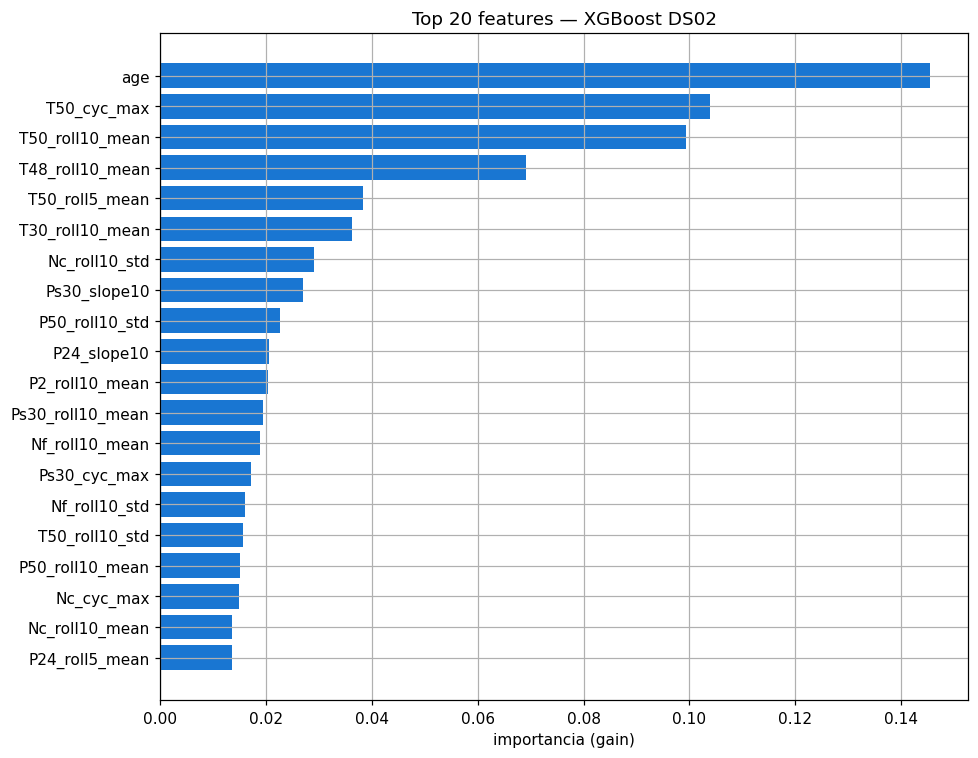

In [ ]:
imp = (pd.DataFrame({'feature': FEATURES, 'gain': model.feature_importances_})
       .sort_values('gain', ascending=False).reset_index(drop=True))

top_gain = imp.gain.iloc[0]
print(f'Feature dominante: {imp.feature.iloc[0]} ({top_gain:.3f})')
if top_gain > 0.9:
    print('⚠️  AVISO: una feature concentra >0.9 de la importancia. Revisar posible leakage.')
else:
    print('OK: la importancia está repartida (sin señal evidente de leakage).')

print('\nTop 15 features:'); print(imp.head(15).to_string(index=False))

plt.figure(figsize=(9, 7))
t = imp.head(20)[::-1]
plt.barh(t.feature, t.gain, color='#1976D2')
plt.xlabel('importancia (gain)'); plt.title('Top 20 features — XGBoost DS02')
plt.tight_layout(); plt.savefig('xgb_ds02_importance.png'); plt.show()

## 7. Persistencia

In [ ]:
import joblib, os
os.makedirs('models', exist_ok=True)
joblib.dump(model,    'models/xgb_ds02_model.joblib')
joblib.dump(FEATURES, 'models/xgb_ds02_features.joblib')
print('Guardado modelo + lista de features en models/')

Guardado modelo + lista de features en models/


## 8. Conclusiones y siguientes pasos

- Baseline honesto (sin fugas), con RMSE ~8 en validación, coherente con la literatura.
- Diagnóstico por hipótesis: refutadas la clase de vuelo y el efecto de `age`; confirmado el
  sesgo por vidas cortas.
- Decisiones tomadas: cap = 57 (criterio físico), `age` se mantiene, features sin fuga.
- Reto abierto: generalizar a vidas fuera de rango → se aborda escalando a la flota completa
  (Fase 2), que aporta variedad de vidas y modos de fallo.